In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

df = pd.read_excel(url)

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df = df.dropna(subset=["InvoiceNo", "StockCode", "InvoiceDate", "Quantity", "UnitPrice"])
df = df.drop_duplicates()
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

print("Final Dataset Shape:", df.shape)
display(df.head())

Final Dataset Shape: (524878, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Overall business summary

In [3]:
total_sales = df["TotalSales"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()
total_quantity = df["Quantity"].sum()

summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Quantity Sold"
    ],
    "Value": [
        total_sales,
        total_orders,
        total_customers,
        total_products,
        total_quantity
    ]
})

display(summary)

,Metric,Value
0,Total Sales,1.064211e+07
1,Total Orders,1.996000e+04
2,Total Customers,4.338000e+03
3,Total Products,3.922000e+03
4,Total Quantity Sold,5.572420e+06


Monthly sales trend

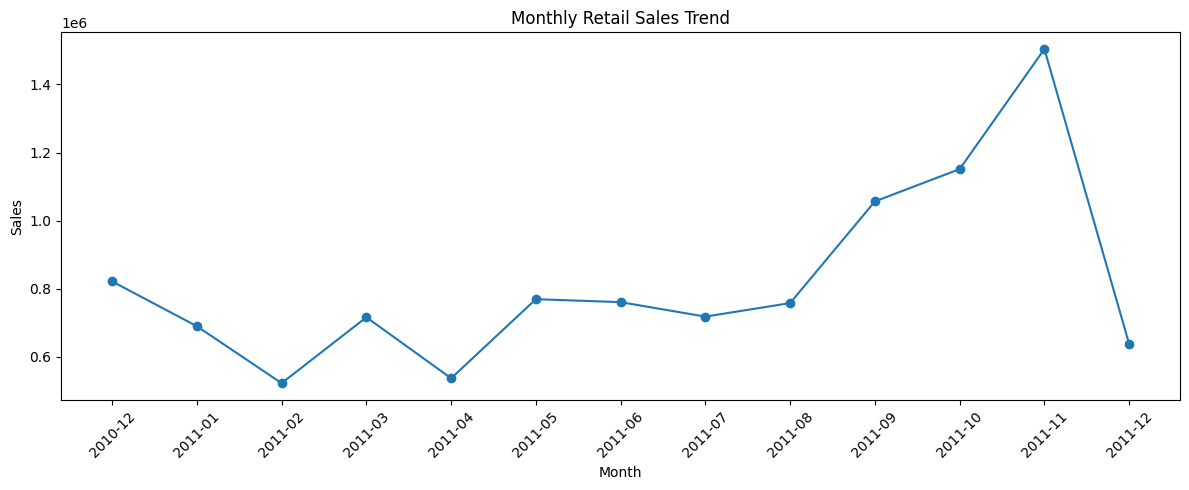

In [4]:
monthly_sales = df.groupby(
    df["InvoiceDate"].dt.to_period("M")
)["TotalSales"].sum().reset_index()

monthly_sales["InvoiceDate"] = monthly_sales["InvoiceDate"].astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales["InvoiceDate"], monthly_sales["TotalSales"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Retail Sales Trend")
plt.tight_layout()
plt.show()

Top countries

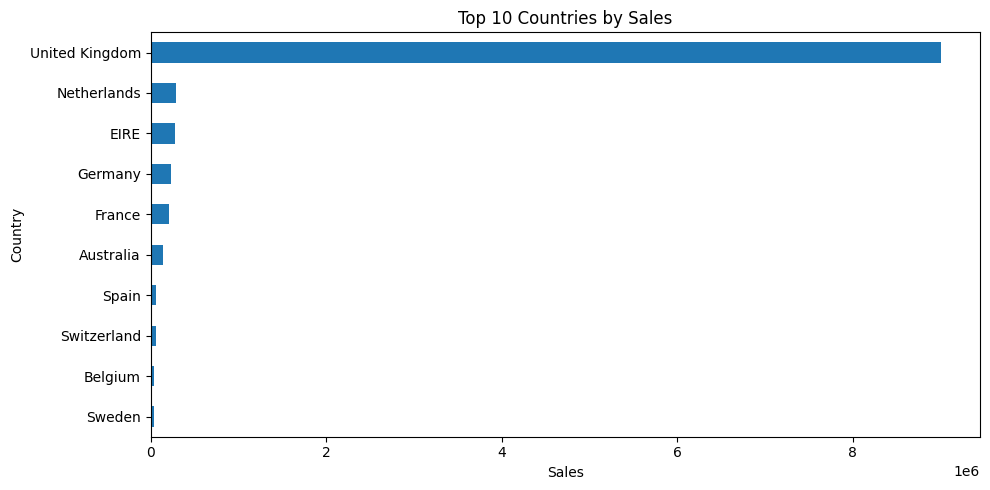

In [5]:
country_sales = df.groupby("Country")["TotalSales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
country_sales.sort_values().plot(kind="barh")
plt.xlabel("Sales")
plt.ylabel("Country")
plt.title("Top 10 Countries by Sales")
plt.tight_layout()
plt.show()

Top products

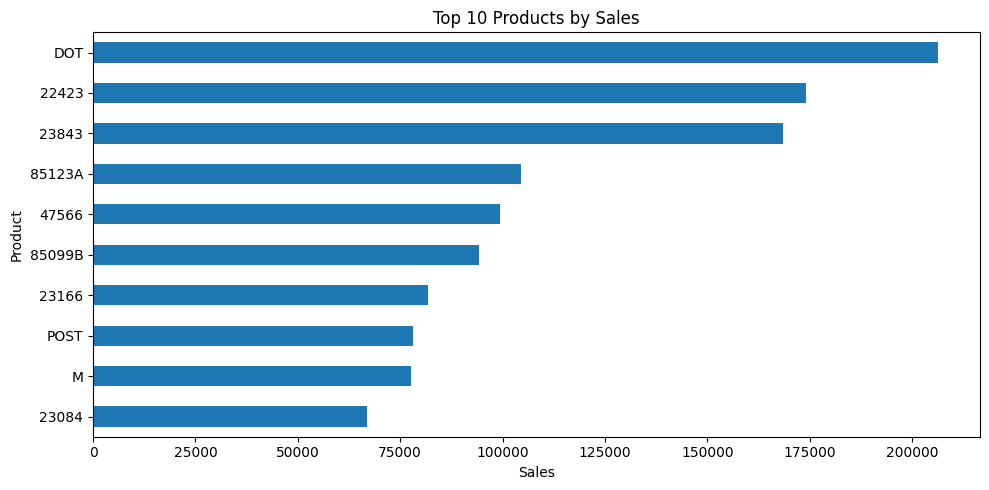

In [6]:
top_products = df.groupby("StockCode")["TotalSales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.sort_values().plot(kind="barh")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.title("Top 10 Products by Sales")
plt.tight_layout()
plt.show()

Customer segmentation summary

In [7]:
customer_df = df.dropna(subset=["CustomerID"]).copy()

reference_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = customer_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalSales", "sum")
).reset_index()

display(rfm.describe())

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


Customer value visualization

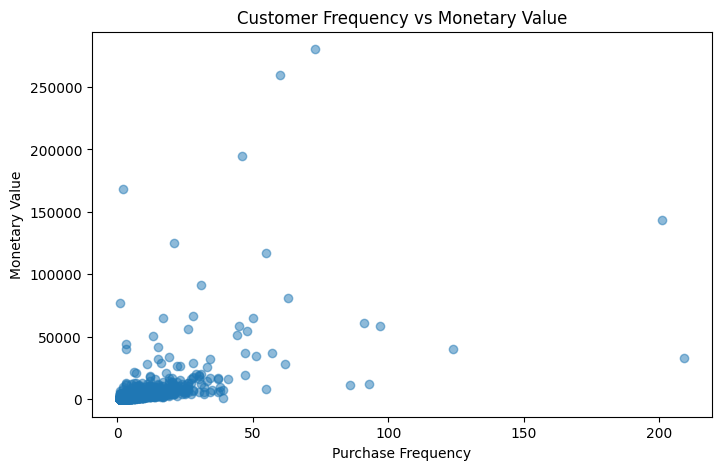

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(rfm["Frequency"], rfm["Monetary"], alpha=0.5)
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.title("Customer Frequency vs Monetary Value")
plt.show()

Pricing strategy summary

In [9]:
pricing = df.groupby(
    ["StockCode", df["InvoiceDate"].dt.to_period("M")]
).agg(
    Price=("UnitPrice", "mean"),
    Demand=("Quantity", "sum"),
    Revenue=("TotalSales", "sum")
).reset_index()

pricing = pricing[(pricing["Price"] > 0) & (pricing["Demand"] > 0)]

print("Pricing Analysis Records:", len(pricing))
display(pricing.head())

Pricing Analysis Records: 34069


,StockCode,InvoiceDate,Price,Demand,Revenue
0,10002,2010-12,1.201000,251,234.41
1,10002,2011-01,0.962857,340,291.37
2,10002,2011-02,1.072857,52,45.76
3,10002,2011-03,1.142500,28,27.70
4,10002,2011-04,0.850000,189,160.65


Overall recommendations

In [10]:
print("========== FINAL RETAIL STRATEGY ==========\n")

print("1. DATA MANAGEMENT")
print("Maintain regular data cleaning and validation to improve analysis quality.")

print("\n2. SALES STRATEGY")
print("Monitor monthly sales trends and focus on high-performing products and markets.")

print("\n3. CUSTOMER STRATEGY")
print("Use customer purchasing behavior to create targeted marketing and retention campaigns.")

print("\n4. FORECASTING")
print("Use historical sales patterns to support inventory and demand planning.")

print("\n5. PRICING")
print("Use price-demand relationships and elasticity analysis to evaluate pricing decisions.")

print("\n6. INTEGRATED STRATEGY")
print("Combine sales trends, forecasts, customer segments, and pricing analysis for better retail decisions.")

========== FINAL RETAIL STRATEGY ==========

1. DATA MANAGEMENT
Maintain regular data cleaning and validation to improve analysis quality.

2. SALES STRATEGY
Monitor monthly sales trends and focus on high-performing products and markets.

3. CUSTOMER STRATEGY
Use customer purchasing behavior to create targeted marketing and retention campaigns.

4. FORECASTING
Use historical sales patterns to support inventory and demand planning.

5. PRICING
Use price-demand relationships and elasticity analysis to evaluate pricing decisions.

6. INTEGRATED STRATEGY
Combine sales trends, forecasts, customer segments, and pricing analysis for better retail decisions.
